# Reverse merging the two datasets:
* 🌾 [Crop Yield agriculture](https://www.kaggle.com/datasets/samuelotiattakorah/agriculture-crop-yield/data)
* 🌾 [Crop Yield Prediction](https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset/data?select=yield_df.csv)

*Enriching each crop with its typical agronomic profile rather than trying to assign field-specific characteristics to country-level observations.*
* The first merge *(Crop Yield Prediction into Crop Yield agriculture)* answered:**Do general country-level variables improve a field-level prediction model?**

* The reverse merge *(Crop Yield agriculture into Crop Yield Prediction)* asks: **Can detailed field-level agronomic information improve a real-world country-level prediction model?**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import statsmodels.api as sm
from scipy.stats import *
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import json
import mlflow
import mlflow.sklearn
from mlflow import MlflowClient
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import ttest_rel
warnings.simplefilter(action='ignore', category=FutureWarning)
from IPython.display import display, HTML
pd.set_option("display.max_columns", None)

## 1.Load Dataset Crop Yield agriculture & overview

In [2]:
data1 = pd.read_csv("../../data/processed_data/yield_agriculture.csv")
data1.head(5)

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,0,0,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,7.248251


In [3]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999769 entries, 0 to 999768
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Region                  999769 non-null  object 
 1   Soil_Type               999769 non-null  object 
 2   Crop                    999769 non-null  object 
 3   Rainfall_mm             999769 non-null  float64
 4   Temperature_Celsius     999769 non-null  float64
 5   Fertilizer_Used         999769 non-null  int64  
 6   Irrigation_Used         999769 non-null  int64  
 7   Weather_Condition       999769 non-null  object 
 8   Days_to_Harvest         999769 non-null  int64  
 9   Yield_tons_per_hectare  999769 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 76.3+ MB


In [4]:
# Quick summary stats for numeric columns
data1.describe()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare
count,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000,999769.000000
mean,550.077823,27.506079,0.500056,0.499606,104.495141,4.650592
std,259.804329,7.220488,0.500000,0.500000,25.953328,1.695166
min,100.000896,15.000034,0.000000,0.000000,60.000000,0.000411
25%,325.062906,21.256078,0.000000,0.000000,82.000000,3.418669
50%,550.229205,27.509509,1.000000,0.000000,104.000000,4.652333
75%,774.797949,33.754459,1.000000,1.000000,127.000000,5.879576
max,999.998098,39.999997,1.000000,1.000000,149.000000,9.963372


In [5]:
print(f"Unique values for column:\n- 'Region': {data1['Region'].unique()}\n- 'Weather_Condition': {data1['Weather_Condition'].unique()}\n- 'Crop': {data1['Crop'].unique()}\n- 'Soil_Type': {data1['Soil_Type'].unique()}")

Unique values for column:
- 'Region': ['West' 'South' 'North' 'East']
- 'Weather_Condition': ['Cloudy' 'Rainy' 'Sunny']
- 'Crop': ['Cotton' 'Rice' 'Barley' 'Soybean' 'Wheat' 'Maize']
- 'Soil_Type': ['Sandy' 'Clay' 'Loam' 'Silt' 'Peaty' 'Chalky']


In [6]:
print("Missing values per column:")
print(data1.isna().sum())
print("\nDuplicate rows:", data1.duplicated().sum())

Missing values per column:
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

Duplicate rows: 0


## 2.Load Dataset Crop Yield Prediction & overview

In [7]:
data2 = pd.read_csv('../../data/processed_data/yield_prediction.csv')
data2.shape

(25932, 7)

In [8]:
data2.head(3)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Maize,1991,29068,1485.0,121.0,15.36
2,Albania,Maize,1992,24876,1485.0,121.0,16.06


In [9]:
data2.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [10]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25932 entries, 0 to 25931
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           25932 non-null  object 
 1   Item                           25932 non-null  object 
 2   Year                           25932 non-null  int64  
 3   hg/ha_yield                    25932 non-null  int64  
 4   average_rain_fall_mm_per_year  25932 non-null  float64
 5   pesticides_tonnes              25932 non-null  float64
 6   avg_temp                       25932 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.4+ MB


In [11]:
data2.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000


In [12]:
print("Missing values per column:")
print(data2.isna().sum())
print("\nDuplicate rows:", data2.duplicated().sum())

Missing values per column:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Duplicate rows: 0


## 3.Merge two datasets

### 1.Fision Crop names

In [13]:
# Same harmonization used in the original (forward) merge, just applied
# in reverse: dataset1's Crop -> dataset2's Item.
CROP_MAPPING_D1_TO_D2 = {
    "Wheat": "Wheat",
    "Rice": "Rice, paddy",
    "Maize": "Maize",
    "Soybean": "Soybeans",
    "Barley": None,
    "Cotton": None,
}

In [14]:
TARGET_COL = "yield_tons_per_ha"  # converted from hg/ha_yield for consistency

### 2.Merge the two datasets on fisioned crops

In [15]:
# ---------------------------------------------------------------------------
# Build the reversed, enriched dataset
# ---------------------------------------------------------------------------
 
def build_reversed_merge(d1: pd.DataFrame, d2: pd.DataFrame) -> pd.DataFrame:
 
    d2 = d2.drop_duplicates().reset_index(drop=True)
 
    # Map dataset1's Crop onto dataset2's Item vocabulary
    d1["Item_harmonized"] = d1["Crop"].map(CROP_MAPPING_D1_TO_D2)
 
    d1_profile = (
        d1.dropna(subset=["Item_harmonized"])
        .groupby("Item_harmonized")
        .agg(
            d1_ref_rainfall_mm=("Rainfall_mm", "mean"),
            d1_ref_temperature_c=("Temperature_Celsius", "mean"),
            d1_ref_fertilizer_rate=("Fertilizer_Used", "mean"),   # proportion True
            d1_ref_irrigation_rate=("Irrigation_Used", "mean"),   # proportion True
            d1_ref_days_to_harvest=("Days_to_Harvest", "mean"),
            d1_ref_yield_tons_per_hectare=("Yield_tons_per_hectare", "mean"),
        )
        .reset_index()
        .rename(columns={"Item_harmonized": "Item"})
    )
 
    merged = d2.merge(d1_profile, on="Item", how="left")
    merged[TARGET_COL] = merged["hg/ha_yield"] / 10000  # hg/ha -> tons/ha
 
    coverage = merged["d1_ref_rainfall_mm"].notna().mean()
    print(f"Rows with dataset1 enrichment available: {coverage:.1%}")
    print("Enrichment coverage by crop:")
    print(merged.groupby("Item")["d1_ref_rainfall_mm"].apply(lambda x: x.notna().mean()))
 
    return merged

In [16]:
merged_df = build_reversed_merge(data1, data2)

Rows with dataset1 enrichment available: 51.7%
Enrichment coverage by crop:
Item
Cassava                 0.0
Maize                   1.0
Plantains and others    0.0
Potatoes                0.0
Rice, paddy             1.0
Sorghum                 0.0
Soybeans                1.0
Sweet potatoes          0.0
Wheat                   1.0
Yams                    0.0
Name: d1_ref_rainfall_mm, dtype: float64


In [17]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25932 entries, 0 to 25931
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           25932 non-null  object 
 1   Item                           25932 non-null  object 
 2   Year                           25932 non-null  int64  
 3   hg/ha_yield                    25932 non-null  int64  
 4   average_rain_fall_mm_per_year  25932 non-null  float64
 5   pesticides_tonnes              25932 non-null  float64
 6   avg_temp                       25932 non-null  float64
 7   d1_ref_rainfall_mm             13394 non-null  float64
 8   d1_ref_temperature_c           13394 non-null  float64
 9   d1_ref_fertilizer_rate         13394 non-null  float64
 10  d1_ref_irrigation_rate         13394 non-null  float64
 11  d1_ref_days_to_harvest         13394 non-null  float64
 12  d1_ref_yield_tons_per_hectare  13394 non-null 

In [18]:
merged_df.head(3)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,d1_ref_rainfall_mm,d1_ref_temperature_c,d1_ref_fertilizer_rate,d1_ref_irrigation_rate,d1_ref_days_to_harvest,d1_ref_yield_tons_per_hectare,yield_tons_per_ha
0,Albania,Maize,1990,36613,1485.0,121.0,16.37,549.291189,27.478547,0.49857,0.500075,104.538292,4.642513,3.6613
1,Albania,Maize,1991,29068,1485.0,121.0,15.36,549.291189,27.478547,0.49857,0.500075,104.538292,4.642513,2.9068
2,Albania,Maize,1992,24876,1485.0,121.0,16.06,549.291189,27.478547,0.49857,0.500075,104.538292,4.642513,2.4876


In [19]:
merged_df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,d1_ref_rainfall_mm,d1_ref_temperature_c,d1_ref_fertilizer_rate,d1_ref_irrigation_rate,d1_ref_days_to_harvest,d1_ref_yield_tons_per_hectare,yield_tons_per_ha
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000,13394.000000,13394.000000,13394.000000,13394.000000,13394.000000,13394.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251,550.147507,27.500598,0.500012,0.499647,104.505830,4.650305,7.697813
std,7.055924,84647.605552,717.391098,57228.568244,6.439402,0.551321,0.015234,0.001029,0.001757,0.029322,0.005021,8.464761
min,1990.000000,50.000000,51.000000,0.040000,1.300000,549.291189,27.478547,0.498570,0.496504,104.457139,4.642513,0.005000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000,549.291189,27.478547,0.498570,0.500075,104.499778,4.642513,1.999600
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000,550.330008,27.499657,0.499883,0.500075,104.516491,4.651849,3.953000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000,550.559846,27.517093,0.501254,0.500906,104.538292,4.653722,10.416800
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000,550.605746,27.517093,0.501254,0.500906,104.538292,4.654701,50.141200


### 3.Save merged dataset

#### Save the whole dataset

In [23]:
output_cols = [
'Area', 'Item', 'Year', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp', 'd1_ref_rainfall_mm',
       'd1_ref_temperature_c', 'd1_ref_fertilizer_rate',
       'd1_ref_irrigation_rate', 'd1_ref_days_to_harvest',
       'd1_ref_yield_tons_per_hectare', 'yield_tons_per_ha'
]

merged_df[output_cols].to_csv("../../data/processed_data/reversed_crop_dataset.csv", index=False)
print("Saved:", merged_df[output_cols].shape)

Saved: (25932, 13)


# 2.Mergerd dataset analyse

## 1.Baseline correlation check

In [28]:
numeric_cols = ['average_rain_fall_mm_per_year','pesticides_tonnes', 'avg_temp', 'd1_ref_rainfall_mm',
       'd1_ref_temperature_c', 'd1_ref_fertilizer_rate','d1_ref_irrigation_rate', 'd1_ref_days_to_harvest',
        'd1_ref_yield_tons_per_hectare','yield_tons_per_ha']
corr = merged_df[numeric_cols].corr()
corr

,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,d1_ref_rainfall_mm,d1_ref_temperature_c,d1_ref_fertilizer_rate,d1_ref_irrigation_rate,d1_ref_days_to_harvest,d1_ref_yield_tons_per_hectare,yield_tons_per_ha
average_rain_fall_mm_per_year,1.000000,0.161483,0.333694,0.011688,-0.060955,-0.056050,-0.093980,-0.037986,-0.024428,-0.004067
pesticides_tonnes,0.161483,1.000000,0.045577,0.043613,0.034755,0.020671,0.001207,-0.052953,0.043335,0.065523
avg_temp,0.333694,0.045577,1.000000,0.008406,-0.090768,-0.065886,-0.148933,-0.020325,-0.044846,-0.110400
d1_ref_rainfall_mm,0.011688,0.043613,0.008406,1.000000,0.830551,0.796720,-0.273268,-0.771377,0.950434,-0.139953
d1_ref_temperature_c,-0.060955,0.034755,-0.090768,0.830551,1.000000,0.899745,0.229261,-0.585418,0.955458,-0.220213
d1_ref_fertilizer_rate,-0.056050,0.020671,-0.065886,0.796720,0.899745,1.000000,-0.083103,-0.303577,0.847031,-0.054980
d1_ref_irrigation_rate,-0.093980,0.001207,-0.148933,-0.273268,0.229261,-0.083103,1.000000,-0.024941,0.028962,-0.275556
d1_ref_days_to_harvest,-0.037986,-0.052953,-0.020325,-0.771377,-0.585418,-0.303577,-0.024941,1.000000,-0.758933,0.289966
d1_ref_yield_tons_per_hectare,-0.024428,0.043335,-0.044846,0.950434,0.955458,0.847031,0.028962,-0.758933,1.000000,-0.216785
yield_tons_per_ha,-0.004067,0.065523,-0.110400,-0.139953,-0.220213,-0.054980,-0.275556,0.289966,-0.216785,1.000000


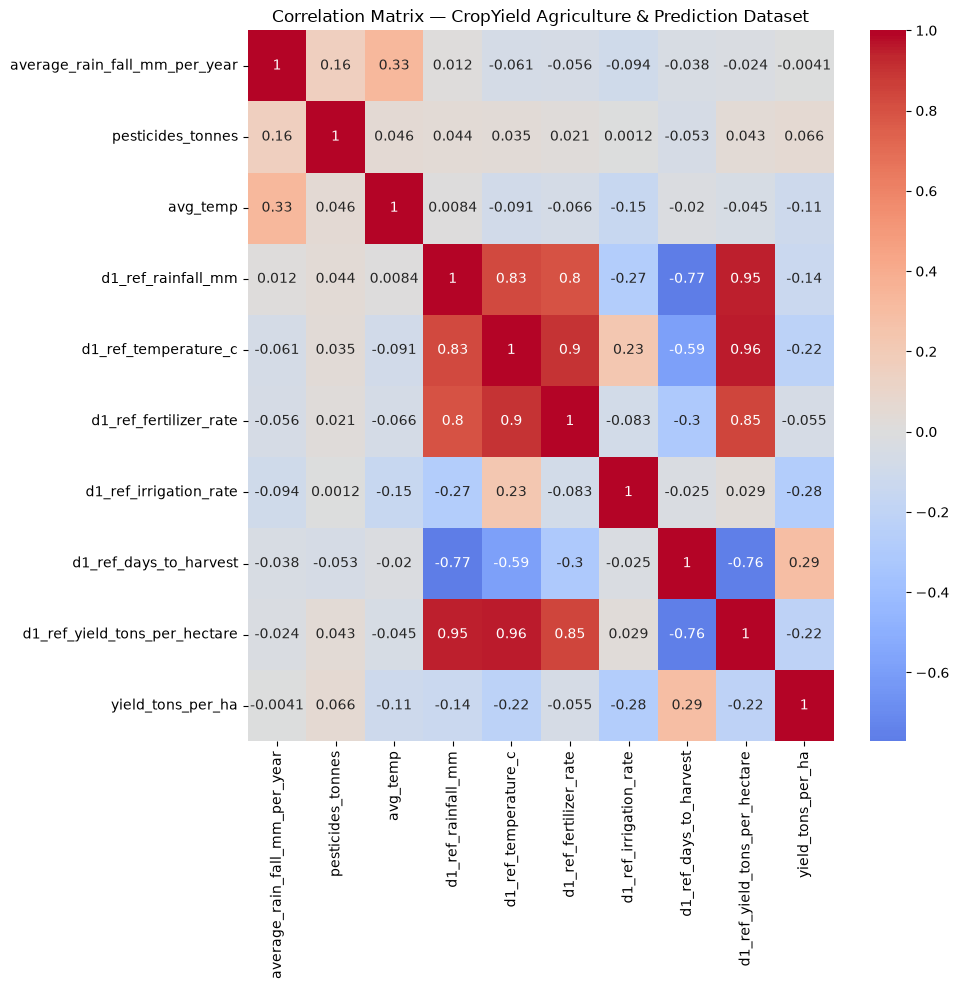

In [29]:
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — CropYield Agriculture & Prediction Dataset")
plt.tight_layout()
plt.show()

**Key observations:**
* The aggregated Dataset1 variables describe crop characteristics, not the environmental conditions of each observation.
* They are highly correlated with each other, introducing redundancy.
* Their relationship with Dataset2's target is weak, except for a modest signal from average days to harvest.
* The `d1_ref_yield_tons_per_hectare` feature should be removed because it introduces target leakage.